In [38]:
# Import necessary libraries 

import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

import tensorflow 
from tensorflow import keras

from keras import Sequential
from keras.layers import Dense,Input

In [39]:
# Fetched this dataset from kaggle 
# The link is as below : 

https://www.kaggle.com/datasets/rakeshrau/social-network-ads

In [40]:
# I have already this downloaded this dataset and have it in the same folder as this code .

In [41]:
# We will be using three columns only to ease our evaluation
df = pd.read_csv('Social_Network_Ads.csv',usecols=['Age','EstimatedSalary','Purchased'])

In [42]:
df.head() # Skim the head

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [43]:
# Also I found that EstimatedSalary was not on the same scale as Age (of course ) so we will normalize them both later
# using StandardScaler

In [44]:
df.shape # We have got 400 rows and three columns

(400, 3)

In [45]:
# Now lets split the dataset and normalize the X set

In [46]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [47]:
X.head() # The Independent variables

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000


In [48]:
y.head() # The output or the dependent variable

0    0
1    0
2    0
3    0
4    0
Name: Purchased, dtype: int64

In [49]:
scale = StandardScaler() # Instantiate the scaler and store in a variable
scale.fit(X) # Always fit first to avoid data leaks

X_scalled = scale.transform(X)

In [50]:
X_scalled[:5] # The first 5 rows now rescalled

array([[-1.78179743, -1.49004624],
       [-0.25358736, -1.46068138],
       [-1.11320552, -0.78528968],
       [-1.01769239, -0.37418169],
       [-1.78179743,  0.18375059]])

In [51]:
# Now let build our neural network

In [52]:
model = Sequential() # Instantiate using Sequential because we are building a sequential model for now
model.add(Input(shape=(X.shape[1],))) # Use this to pass the now of cols, in the dataset 

# Add the layer moving from input to output , and also place the activation function in each 
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [53]:
model.summary() # Call this to look at the summary of the parameters and layers we made 

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [54]:
# Now compile the model with the loss function for the model
model.compile(loss='binary_crossentropy',metrics=['accuracy'])

In [55]:
# This was the basic setup for the problem before we apply differnt types of gradient descent on the neural network to learn parameters

### Batch Gradient Descent

In [ ]:
# Basically the tweak here is we set the batch size when fitting equal to X.shape[0] because 
# we will be only updating all the paramters once each epoch
# So no_of_updates = epoch

In [57]:
# Also we will be noting down the time differnce for each algorithm to compare later 

In [82]:
start_bgd = time.time() # <-- Note the start 

history = model.fit(  
            X_scalled, # Make sure to pass X_Scalled NOT X !!! 
            y,
            epochs = 10, # I took a small value for demonstration only can use upto 100 or 500 in PC's with dedicated GPU and TPU
            batch_size = X.shape[0], # Also this is the most important
            validation_split = 0.2 # Validation set to validate
            )

end_bgd = time.time() # <-- Note the end

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 505ms/step - accuracy: 0.9031 - loss: 0.2647 - val_accuracy: 0.9750 - val_loss: 0.1602
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 920ms/step - accuracy: 0.9031 - loss: 0.2646 - val_accuracy: 0.9750 - val_loss: 0.1603
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - accuracy: 0.9031 - loss: 0.2645 - val_accuracy: 0.9750 - val_loss: 0.1605
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.9031 - loss: 0.2644 - val_accuracy: 0.9750 - val_loss: 0.1606
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - accuracy: 0.9031 - loss: 0.2642 - val_accuracy: 0.9750 - val_loss: 0.1608
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 0.9031 - loss: 0.2641 - val_accuracy: 0.9750 - val_loss: 0.1609
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.9031 - loss: 0.2640 - val_accuracy: 0.9750 - val_loss: 0.1611
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.9031 - loss: 0.2639 - val_accuracy: 0.9750 - val_loss:

In [83]:
time_bgd = end_bgd - start_bgd

In [84]:
time_bgd 
# Took these much seconds on my laptop ( Depends on the place where this code block was running )
# I ran this on ram and with no gpu so this could be faster

4.495933294296265

In [85]:
# Now we will also plot the loss over time to understand the nature of bgd more

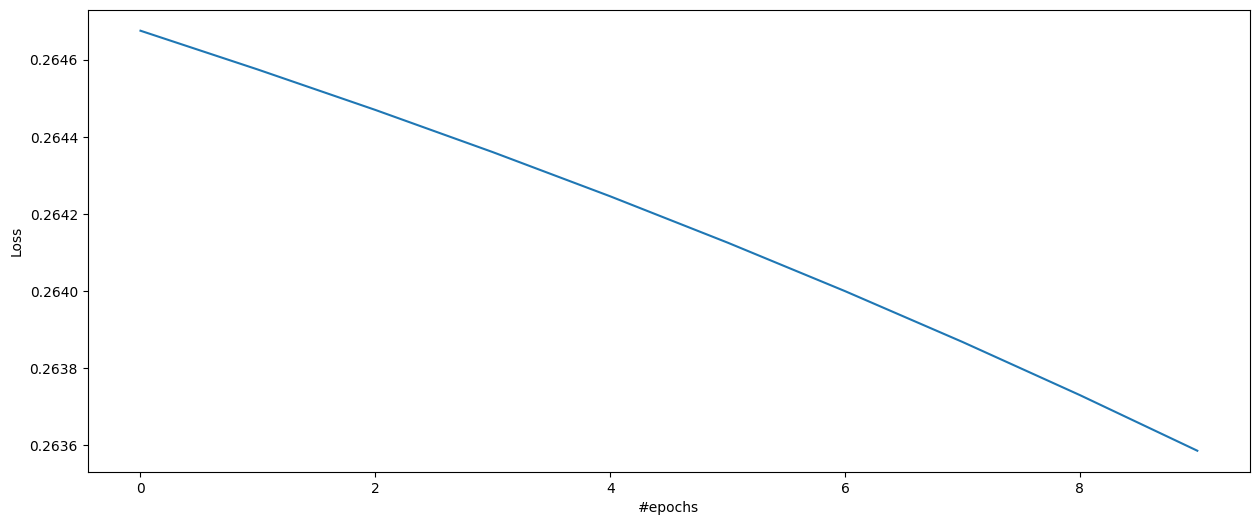

In [86]:
plt.figure(figsize=(15,6))
plt.plot(history.history['loss']) # Plots the loss values across epochs
plt.ylabel('Loss')
plt.xlabel('#epochs')
plt.show()

In [73]:
# As expected we got a linear graph as in batch gradient descent the loss is linear decreasing and tends to the precise solution

### Stochastic Gradient Descent 

In [74]:
# Now the tweak here is we set the batch size when fitting equal to 1 because 
# we will updating each row in a single epoch so : 
# So no_of_updates = epoch*X.shape[0]

In [75]:
start_sgd = time.time() # <-- Note the start 

history = model.fit(  
            X_scalled, # Make sure to pass X_Scalled NOT X !!! 
            y,
            epochs = 10, 
            batch_size = 1, # Pass 1 here now
            validation_split = 0.2 # Validation set to validate
            )

end_sgd = time.time() # <-- Note the end

Epoch 1/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.8906 - loss: 0.2685 - val_accuracy: 0.9625 - val_loss: 0.1664
Epoch 2/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.8969 - loss: 0.2723 - val_accuracy: 0.9500 - val_loss: 0.1709
Epoch 3/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.8906 - loss: 0.2702 - val_accuracy: 0.9625 - val_loss: 0.1625
Epoch 4/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8969 - loss: 0.2707 - val_accuracy: 0.9750 - val_loss: 0.1608
Epoch 5/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8906 - loss: 0.2677 - val_accuracy: 0.9750 - val_loss: 0.1536
Epoch 6/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8969 - loss: 0.2711 - val_accuracy: 0.9750 - val_loss: 0.1581
Epoch 7/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8969 - loss: 0.2722 - val_accuracy: 0.9750 - val_loss: 0.1615
Epoch 8/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8906 - loss: 0.2730 - val_accu

In [76]:
time_sgd = end_sgd - start_sgd

In [77]:
time_sgd # As expected took a lot longer than batch gradient descent

62.0483341217041

In [78]:
# Now plotting the loss

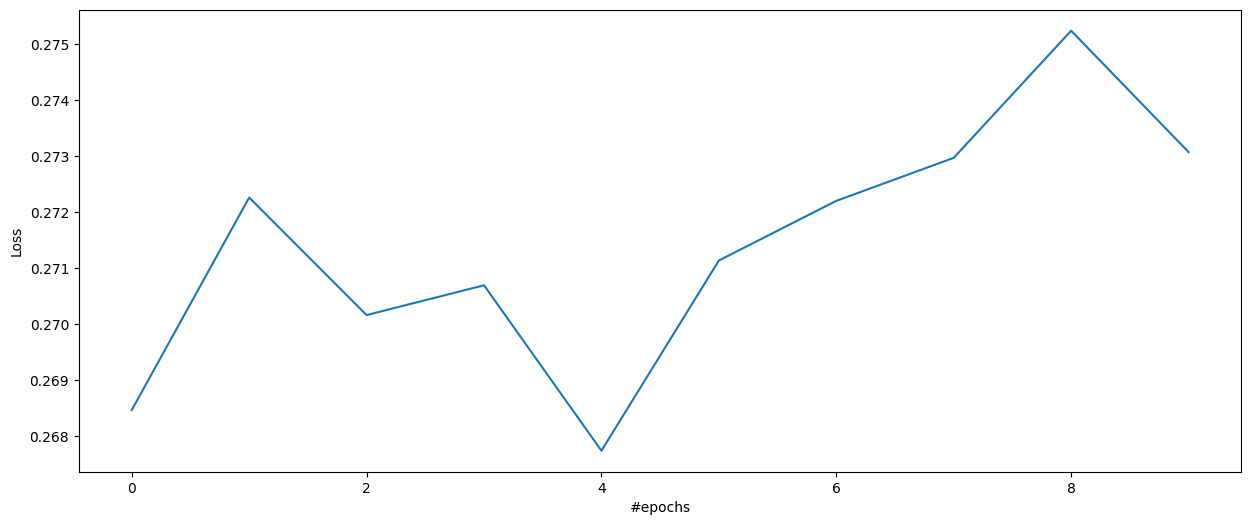

In [81]:
plt.figure(figsize=(15,6))
plt.plot(history.history['loss']) 
plt.ylabel('Loss')
plt.xlabel('#epochs')
plt.show()

In [80]:
# As expected a stochastic graph as we take random values and update values in a random manner